In [11]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [12]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [13]:

X_train = X_train / 255
X_test = X_test / 255

In [14]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [15]:
model = keras.Sequential([
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 879us/step - accuracy: 0.8746 - loss: 0.4741
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9150 - loss: 0.3038
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9210 - loss: 0.2834
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9238 - loss: 0.2730
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 933us/step - accuracy: 0.9253 - loss: 0.2666


In [16]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9245 - loss: 0.2677  


[0.2676543593406677, 0.9244999885559082]

In [17]:
y_predicted = model.predict(X_test_flattened)
y_predicted

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step


array([[3.64103988e-02, 2.98000145e-07, 4.47960459e-02, ...,
        9.99847651e-01, 1.01162784e-01, 7.27812171e-01],
       [4.53694910e-01, 4.71394835e-03, 9.99138951e-01, ...,
        1.39105524e-12, 8.59227479e-02, 8.43347170e-10],
       [5.12938772e-04, 9.92947638e-01, 5.93356371e-01, ...,
        1.43716365e-01, 3.36429000e-01, 6.22055754e-02],
       ...,
       [6.42775467e-06, 4.02687874e-06, 6.03543653e-04, ...,
        3.02338183e-01, 5.38675547e-01, 8.63691449e-01],
       [1.71499894e-04, 1.38143907e-04, 1.11659683e-04, ...,
        4.03582344e-05, 6.16867244e-01, 1.42713412e-04],
       [1.10047087e-02, 2.16994700e-10, 8.88966545e-02, ...,
        2.39795970e-08, 1.82040196e-04, 8.85734551e-07]],
      shape=(10000, 10), dtype=float32)

In [18]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]
y_predicted_labels

[np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4),
 np.int64(9),
 np.int64(6),
 np.int64(9),
 np.int64(0),
 np.int64(6),
 np.int64(9),
 np.int64(0),
 np.int64(1),
 np.int64(5),
 np.int64(9),
 np.int64(7),
 np.int64(3),
 np.int64(4),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(5),
 np.int64(4),
 np.int64(0),
 np.int64(7),
 np.int64(4),
 np.int64(0),
 np.int64(1),
 np.int64(3),
 np.int64(1),
 np.int64(3),
 np.int64(0),
 np.int64(7),
 np.int64(2),
 np.int64(7),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(1),
 np.int64(7),
 np.int64(4),
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(1),
 np.int64(2),
 np.int64(4),
 np.int64(4),
 np.int64(6),
 np.int64(3),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(9),
 np.int64(5),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(2),
 np.int64(7),
 np.int64(4),
 np.int64(2),
 np.int64(4),
 np.int64(3),
 np.int64(0),
 np.int64(7),
 np.in

In [19]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 966,    0,    1,    1,    0,    5,    3,    3,    1,    0],
       [   0, 1111,    3,    2,    0,    1,    4,    2,   12,    0],
       [   9,    9,  912,   14,   10,    5,   13,   12,   43,    5],
       [   4,    0,   15,  907,    0,   37,    2,   12,   23,   10],
       [   2,    1,    4,    1,  907,    0,    8,    4,    8,   47],
       [  10,    3,    2,   25,    7,  785,   13,   10,   29,    8],
       [  11,    3,    6,    1,    8,   15,  910,    2,    2,    0],
       [   2,    5,   20,    5,    5,    0,    0,  952,    3,   36],
       [   9,    7,    6,   19,    9,   26,    9,   12,  866,   11],
       [  11,    7,    1,    8,   18,    8,    0,   21,    6,  929]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

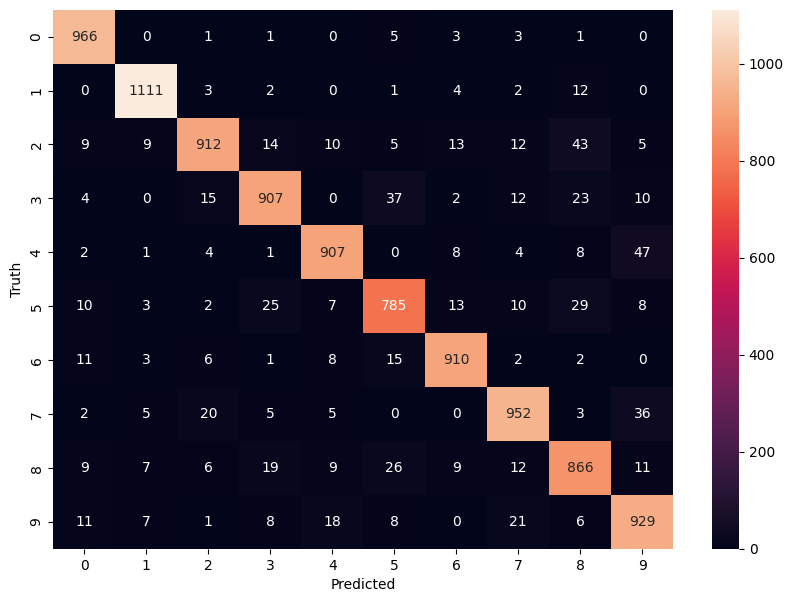

In [20]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')